<a href="https://colab.research.google.com/github/Romanfng7/Tarea-Semanal-0/blob/main/Trabajo_Semanal_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Trabajo Semanal 4**


## **Teoria de Circuito 2**
**Alumno**: Roman Nicolas Funes
**Legajo**: 221.287-0

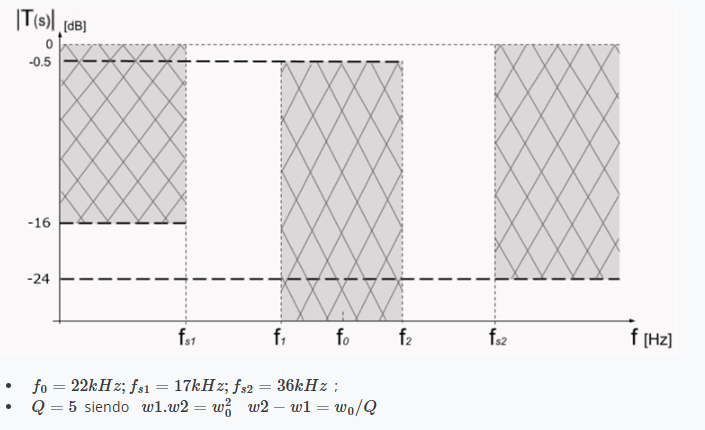

## **Ejercicio 1**


**Obtener la plantilla de atenuación normalizada en frecuencia. Indicar los valores de $\alpha_{max}$ y de $\alpha_{min}$**

* Frecuencia central: $f_0 = 22\text{ kHz}$
* Factor de calidad: $Q = 5$
* Frecuencias de detención: $f_{s1} = 17\text{ kHz}$ y $f_{s2} = 36\text{ kHz}$
* Atenuación máxima: $\alpha_{max} = 0.5\text{ dB}$
* Atenuaciones mínimas: $\alpha_{min1} = 16\text{ dB}$ y $\alpha_{min2} = 24\text{ dB}$

Fórmula de transformación:
$$\omega = Q \cdot \frac{f^2 - f_0^2}{f \cdot f_0}$$

* **Para $f_{s1} = 17\text{ kHz}$:**
  $$\omega_{s1} = 5 \cdot \frac{17^2 - 22^2}{17 \cdot 22} \approx -2.607 \implies |\omega_{s1}| = 2.607$$

* **Para $f_{s2} = 36\text{ kHz}$:**
  $$\omega_{s2} = 5 \cdot \frac{36^2 - 22^2}{36 \cdot 22} \approx 5.126 \implies |\omega_{s2}| = 5.126$$

Cálculo del parámetro de rizado:
$$\epsilon^2 = 10^{\alpha_{max}/10} - 1 = 10^{0.5/10} - 1 \approx 0.122$$

Fórmula de atenuación para Chebyshev:
$$\alpha_{min} = 10 \cdot \log[1 + \epsilon^2 \cdot \cosh^2(n \cdot \cosh^{-1}\omega_s)]$$

* **Evaluación para $|\omega_{s1}| = 2.607$:**
  * Para $n = 1$: $\alpha_{min} \approx 2.623\text{ dB}$
  * Para $n = 2$: $\alpha_{min} \approx 13.085\text{ dB}$
  * Para $n = 3$: $\alpha_{min} \approx 26.867\text{ dB} \implies n = 3 \text{ para } \omega_{s1}$

* **Evaluación para $|\omega_{s2}| = 5.126$:**
  * Para $n = 1$: $\alpha_{min} \approx 6.238\text{ dB}$
  * Para $n = 2$: $\alpha_{min} \approx 25.122\text{ dB} \implies n = 2 \text{ para } \omega_{s2}$
  * Para $n = 3$: $\alpha_{min} \approx 45.240\text{ dB}$

**Criterio de diseño:** . El caso más restrictivo con $n=2$ llega a $\alpha_{min} \approx 13.085\text{ dB}$, apenas $3\text{ dB}$ menos que el requisito. A fines de simplificar el diseño, usaré **$n=2$** que se aproxima a los requisitos.

## **Ejercicio 2**


**Obtener la función transferencia normalizada del prototipo pasa bajo que satisfaga el requerimiento del filtro pasa banda.**

$$\epsilon = \sqrt{10^{\alpha_{max}/10} - 1} \approx 0.349$$
$$a = \frac{1}{n}\sinh^{-1}\left(\frac{1}{\epsilon}\right) = \frac{1}{2}\sinh^{-1}\left(\frac{1}{0.349}\right) \approx 0.887$$
$$\theta_k = \frac{(2k - 1)\pi}{2n} = \frac{(2k - 1)\pi}{4}$$

Cálculo de los componentes reales e imaginarios de los polos ($s_k = \sigma_k + j\omega_k$):
$$\sigma_k = -\sinh(a)\sin(\theta_k)$$
$$\omega_k = \cosh(a)\cos(\theta_k)$$

$$s_k = -\sinh(a)\sin\left(\frac{(2k - 1)\pi}{4}\right) + j\cosh(a)\cos\left(\frac{(2k - 1)\pi}{4}\right)$$

Dando como resultado los polos conjugados:
$$s_1 = -0.713 - j1.004$$
$$s_2 = -0.713 + j1.004$$

Multiplicando los binomios del denominador:
$$(s - s_1)\cdot(s - s_2) = (s + 0.713 + j1.004)\cdot(s + 0.713 - j1.004) = s^2 + 1.426s + 1.516$$

Función de transferencia normalizada del prototipo pasa-bajos $T_{LP}(s)$:
$$T_{LP}(s) = \frac{\frac{\sigma^2 + \omega^2}{\sqrt{1 + \epsilon^2}}}{(s - s_1)\cdot(s - s_2)} = \frac{1.431}{s^2 + 1.426s + 1.516}$$

## **Ejercicio 3**


$$T_{BP}(s') = \frac{1.431}{s'^2 + 1.426s' + 1.516}$$

Núcleo de transformación:
$$s' = Q \cdot \frac{s^2 + 1}{s} = 5 \cdot \frac{s^2 + 1}{s}$$

Reemplazando en $T_{BP}(s')$ obtenemos la transferencia total de orden 4:
$$T_{BP}(s) = \frac{1.431}{\left(5 \cdot \frac{s^2+1}{s}\right)^2 + 1.426 \cdot 5 \cdot \frac{s^2+1}{s} + 1.516} = \frac{0.05724s^2}{s^4 + 0.2852s^3 + 2.06064s^2 + 0.2852s + 1}$$

El polinomio denominador responde a la estructura $s^4 + As^3 + Bs^2 + As + 1$ donde $A = 0.2852$ y $B = 2.06064$.

Para factorizar en secciones de segundo orden (SOS), definimos $x = \omega_1 + \omega_2$:
$$x^2 = \frac{B + 2 + \sqrt{(B + 2)^2 - 4A^2}}{2} \implies x = 2.0101$$
$$Q_{SOS} = \frac{x}{A} = \frac{2.0101}{0.2852} = 7.048$$

Planteamos la ecuación resolvente para las frecuencias propias $\omega^2 - x\omega + 1 = 0$:
$$\omega_1 = 1.1056 \implies \omega_1^2 \approx 1.222$$
$$\omega_2 = 0.9044 \implies \omega_2^2 \approx 0.818$$

La expresión en SOS queda estructurada como:
$$T_{BP}(s) = \left( \frac{K_1 s}{s^2 + \frac{\omega_1}{Q_{SOS}}s + \omega_1^2} \right) \cdot \left( \frac{K_2 s}{s^2 + \frac{\omega_2}{Q_{SOS}}s + \omega_2^2} \right)$$
$$T_{BP}(s) = \left( \frac{K_1 s}{s^2 + 0.1569s + 1.222} \right) \cdot \left( \frac{K_2 s}{s^2 + 0.1283s + 0.818} \right)$$

Considerando que $K_1 \cdot K_2 = 0.05724$, asumimos una distribución equitativa de ganancia:
$$K_1 = K_2 \approx 0.2392$$

Por lo tanto, las dos funciones SOS finales son:
$$T_1(s) = \frac{0.2392s}{s^2 + 0.1569s + 1.222}$$
$$T_2(s) = \frac{0.2392s}{s^2 + 0.1283s + 0.818}$$


## **Ejercicio 4**


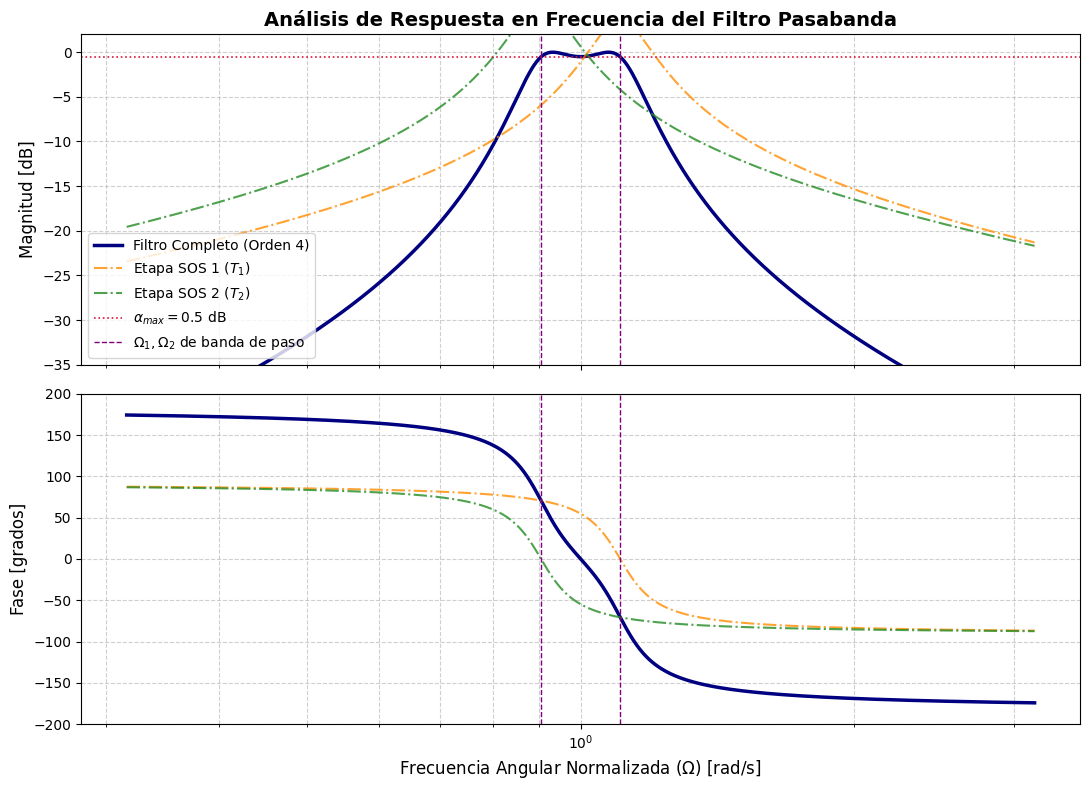

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

num_total = [0.05724, 0, 0]
den_total = [1, 0.2852, 2.06064, 0.2852, 1]
sys_total = signal.TransferFunction(num_total, den_total)

num_sos1 = [0.2392, 0]
den_sos1 = [1, 0.1569, 1.222]
sys_sos1 = signal.TransferFunction(num_sos1, den_sos1)

num_sos2 = [0.2392, 0]
den_sos2 = [1, 0.1283, 0.818]
sys_sos2 = signal.TransferFunction(num_sos2, den_sos2)

w1_corte = 0.9044
w2_corte = 1.1056

w = np.logspace(-0.5, 0.5, 2000)

w_tot, mag_tot, phase_tot = signal.bode(sys_total, w)
w_sos1, mag_1, phase_1 = signal.bode(sys_sos1, w)
w_sos2, mag_2, phase_2 = signal.bode(sys_sos2, w)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

ax1.semilogx(w_tot, mag_tot, label='Filtro Completo (Orden 4)', color='navy', linewidth=2.5)
ax1.semilogx(w_sos1, mag_1, label='Etapa SOS 1 ($T_1$)', linestyle='-.', color='darkorange', alpha=0.8)
ax1.semilogx(w_sos2, mag_2, label='Etapa SOS 2 ($T_2$)', linestyle='-.', color='forestgreen', alpha=0.8)

ax1.axhline(-0.5, color='crimson', linestyle=':', linewidth=1.2, label=r'$\alpha_{max} = 0.5$ dB')
ax1.axvline(w1_corte, color='purple', linestyle='--', linewidth=1, label=r'$\Omega_1, \Omega_2$ de banda de paso')
ax1.axvline(w2_corte, color='purple', linestyle='--', linewidth=1)

ax1.set_title('Análisis de Respuesta en Frecuencia del Filtro Pasabanda', fontsize=14, fontweight='bold')
ax1.set_ylabel('Magnitud [dB]', fontsize=12)
ax1.set_ylim([-35, 2])
ax1.grid(True, which="both", linestyle="--", alpha=0.6)
ax1.legend(loc='lower left', fontsize=10)

ax2.semilogx(w_tot, phase_tot, color='navy', linewidth=2.5, label='Fase Total')
ax2.semilogx(w_sos1, phase_1, linestyle='-.', color='darkorange', alpha=0.8)
ax2.semilogx(w_sos2, phase_2, linestyle='-.', color='forestgreen', alpha=0.8)

ax2.axvline(w1_corte, color='purple', linestyle='--', linewidth=1)
ax2.axvline(w2_corte, color='purple', linestyle='--', linewidth=1)

ax2.set_xlabel(r'Frecuencia Angular Normalizada ($\Omega$) [rad/s]', fontsize=12)
ax2.set_ylabel('Fase [grados]', fontsize=12)
ax2.set_ylim([-200, 200])
ax2.grid(True, which="both", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

## **Bonus**


#### 1. Despeje para la Sección SOS 1
Partiendo del denominador normalizado:
$$s^2 + 0.1569s + 1.222 = s^2 + \frac{R_1}{L_1}s + \frac{1}{L_1 C_1}$$

Asumiendo el valor base del inductor de la propuesta original $L_1 = 1\text{ H}$:
$$\frac{R_1}{1} = 0.1569 \implies R_1 = 0.1569\,\Omega$$
$$\frac{1}{1 \cdot C_1} = 1.222 \implies C_1 = \frac{1}{1.222} \approx 0.8183\text{ F}$$

---

#### 2. Despeje para la Sección SOS 2
Partiendo del denominador normalizado:
$$s^2 + 0.1283s + 0.818 = s^2 + \frac{R_2}{L_2}s + \frac{1}{L_2 C_2}$$

Asumiendo el valor base del inductor de la propuesta original $L_2 = 1\text{ H}$:
$$\frac{R_2}{1} = 0.1283 \implies R_2 = 0.1283\,\Omega$$
$$\frac{1}{1 \cdot C_2} = 0.818 \implies C_2 = \frac{1}{0.818} \approx 1.2225\text{ F}$$



---


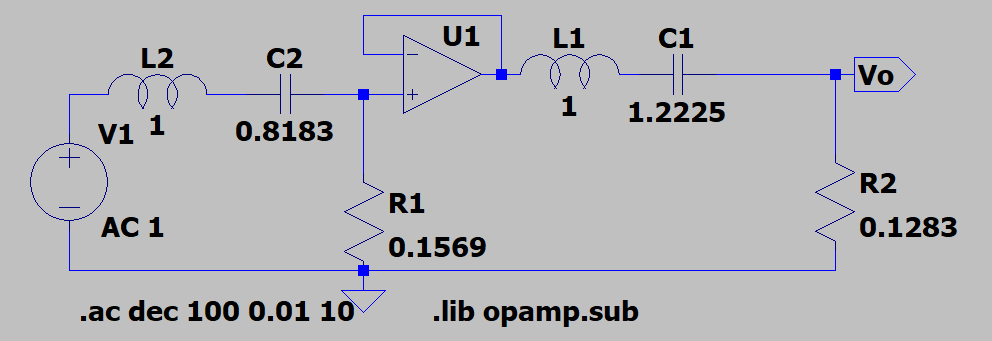

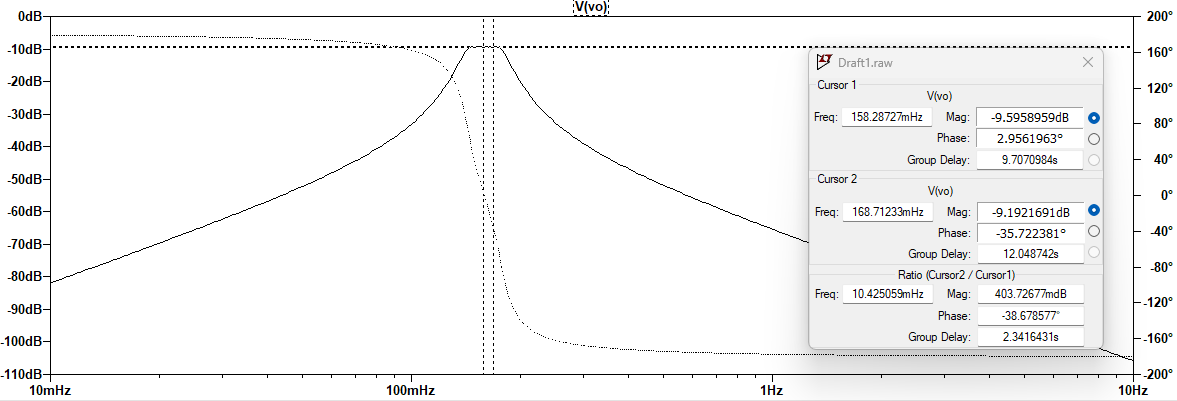


$$T_{LP}(s) = \frac{1.431}{s^2 + 1.426s + 1.516}$$

Sustituyendo el núcleo de transformación $s = \frac{1}{s}$:
$$T_{HP}(s) = \frac{1.431}{\left(\frac{1}{s}\right)^2 + 1.426\left(\frac{1}{s}\right) + 1.516}$$

$$T_{HP}(s) = \frac{1.431 \cdot s^2}{1 + 1.426s + 1.516s^2}$$

$$T_{HP}(s) = \frac{1.431s^2}{1.516s^2 + 1.426s + 1}$$

$$T_{HP}(s) = \frac{\left(\frac{1.431}{1.516}\right)s^2}{s^2 + \left(\frac{1.426}{1.516}\right)s + \frac{1}{1.516}}$$

$$T_{HP}(s) = \frac{0.9439s^2}{s^2 + 0.9406s + 0.6596}$$


* Factor de calidad de la etapa: $Q = \frac{\omega_0}{0.9406} = \frac{0.812}{0.9406} \approx 0.863$